In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Website_Traffic_Dataset_Updated.csv")

In [3]:
df.head()

,Date,Hour,Traffic Source,Device Type,Country,Landing Page,Sessions,Engaged Sessions,Users,Avg Engagement Time per Session (mins),Engaged Sessions per User,Event Count,Events per Session,Engagement Rate (%),Bounce Rate (%),Conversion Count,Conversion Rate (%),Session Primary Channel Group (Default Channel Group)
0,2024-02-23,8,Direct,Tablet,UK,/services,169,93,144,2.38,0.65,416,2.46,55.03,44.97,24,16.67,Direct
1,2024-02-23,5,Social Media,Desktop,Australia,/landing-page,218,161,162,12.78,0.99,1106,5.07,73.85,26.15,0,0.00,Organic Social
2,2024-03-12,0,Paid Ads,Desktop,UK,/landing-page,403,193,335,16.34,0.58,1185,2.94,47.89,52.11,18,5.37,Paid Search
3,2025-08-10,15,Direct,Mobile,USA,/checkout,351,336,313,1.14,1.07,1951,5.56,95.73,4.27,43,13.74,Direct
4,2025-10-16,16,Email,Tablet,Australia,/signup,658,236,522,7.47,0.45,7617,11.58,35.87,64.13,111,21.26,Email


In [9]:
df.columns = ["Date","Hour","Traffic Source","Device Type","Country","Landing Page","Sessions","Engaged Sessions","Users","Avg Engagement Time per Session (mins)","Engaged Sessions per User","Event Count","Events per Session","Engagement Rate (%)","Bounce Rate (%)","Conversion Count","Conversion Rate (%)","Channel Group","Date_Hour"]

In [8]:
print(len(df.columns))
print(df.columns)

19
Index(['Date', 'Hour', 'Traffic Source', 'Device Type', 'Country',
       'Landing Page', 'Sessions', 'Engaged Sessions', 'Users',
       'Avg Engagement Time per Session (mins)', 'Engaged Sessions per User',
       'Event Count', 'Events per Session', 'Engagement Rate (%)',
       'Bounce Rate (%)', 'Conversion Count', 'Conversion Rate (%)',
       'Session Primary Channel Group (Default Channel Group)', 'Date_Hour'],
      dtype='object')


In [10]:
df.head()

,Date,Hour,Traffic Source,Device Type,Country,Landing Page,Sessions,Engaged Sessions,Users,Avg Engagement Time per Session (mins),Engaged Sessions per User,Event Count,Events per Session,Engagement Rate (%),Bounce Rate (%),Conversion Count,Conversion Rate (%),Channel Group,Date_Hour
0,2024-02-23,8,Direct,Tablet,UK,/services,169,93,144,2.38,0.65,416,2.46,55.03,44.97,24,16.67,Direct,2024-02-23 08:00:00
1,2024-02-23,5,Social Media,Desktop,Australia,/landing-page,218,161,162,12.78,0.99,1106,5.07,73.85,26.15,0,0.00,Organic Social,2024-02-23 05:00:00
2,2024-03-12,0,Paid Ads,Desktop,UK,/landing-page,403,193,335,16.34,0.58,1185,2.94,47.89,52.11,18,5.37,Paid Search,2024-03-12 00:00:00
3,2025-08-10,15,Direct,Mobile,USA,/checkout,351,336,313,1.14,1.07,1951,5.56,95.73,4.27,43,13.74,Direct,2025-08-10 15:00:00
4,2025-10-16,16,Email,Tablet,Australia,/signup,658,236,522,7.47,0.45,7617,11.58,35.87,64.13,111,21.26,Email,2025-10-16 16:00:00


In [14]:
df.columns = df.columns.str.strip()
df = df.drop(columns=["Unnamed: 0", "Hour"], errors="ignore")

In [16]:
print(len(df.columns))
print(df.columns)


17
Index(['Traffic Source', 'Device Type', 'Country', 'Landing Page', 'Sessions',
       'Engaged Sessions', 'Users', 'Avg Engagement Time per Session (mins)',
       'Engaged Sessions per User', 'Event Count', 'Events per Session',
       'Engagement Rate (%)', 'Bounce Rate (%)', 'Conversion Count',
       'Conversion Rate (%)', 'Channel Group', 'Date_Hour'],
      dtype='object')


In [18]:
cols = list(df.columns)

cols = [cols[-1]] + cols[:-1]

df = df[cols]

In [19]:
df.head()

,Date_Hour,Traffic Source,Device Type,Country,Landing Page,Sessions,Engaged Sessions,Users,Avg Engagement Time per Session (mins),Engaged Sessions per User,Event Count,Events per Session,Engagement Rate (%),Bounce Rate (%),Conversion Count,Conversion Rate (%),Channel Group
0,2024-02-23 08:00:00,Direct,Tablet,UK,/services,169,93,144,2.38,0.65,416,2.46,55.03,44.97,24,16.67,Direct
1,2024-02-23 05:00:00,Social Media,Desktop,Australia,/landing-page,218,161,162,12.78,0.99,1106,5.07,73.85,26.15,0,0.00,Organic Social
2,2024-03-12 00:00:00,Paid Ads,Desktop,UK,/landing-page,403,193,335,16.34,0.58,1185,2.94,47.89,52.11,18,5.37,Paid Search
3,2025-08-10 15:00:00,Direct,Mobile,USA,/checkout,351,336,313,1.14,1.07,1951,5.56,95.73,4.27,43,13.74,Direct
4,2025-10-16 16:00:00,Email,Tablet,Australia,/signup,658,236,522,7.47,0.45,7617,11.58,35.87,64.13,111,21.26,Email


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Date_Hour                               1500 non-null   datetime64[ns]
 1   Traffic Source                          1500 non-null   object        
 2   Device Type                             1500 non-null   object        
 3   Country                                 1500 non-null   object        
 4   Landing Page                            1500 non-null   object        
 5   Sessions                                1500 non-null   int64         
 6   Engaged Sessions                        1500 non-null   int64         
 7   Users                                   1500 non-null   int64         
 8   Avg Engagement Time per Session (mins)  1500 non-null   float64       
 9   Engaged Sessions per User               1500 non-nul

In [24]:
df["Hour"] = pd.to_datetime(df["Date_Hour"], errors="coerce").dt.hour

In [25]:
df.head()

,Date_Hour,Traffic Source,Device Type,Country,Landing Page,Sessions,Engaged Sessions,Users,Avg Engagement Time per Session (mins),Engaged Sessions per User,Event Count,Events per Session,Engagement Rate (%),Bounce Rate (%),Conversion Count,Conversion Rate (%),Channel Group,Hour
0,2024-02-23 08:00:00,Direct,Tablet,UK,/services,169,93,144,2.38,0.65,416,2.46,55.03,44.97,24,16.67,Direct,8
1,2024-02-23 05:00:00,Social Media,Desktop,Australia,/landing-page,218,161,162,12.78,0.99,1106,5.07,73.85,26.15,0,0.00,Organic Social,5
2,2024-03-12 00:00:00,Paid Ads,Desktop,UK,/landing-page,403,193,335,16.34,0.58,1185,2.94,47.89,52.11,18,5.37,Paid Search,0
3,2025-08-10 15:00:00,Direct,Mobile,USA,/checkout,351,336,313,1.14,1.07,1951,5.56,95.73,4.27,43,13.74,Direct,15
4,2025-10-16 16:00:00,Email,Tablet,Australia,/signup,658,236,522,7.47,0.45,7617,11.58,35.87,64.13,111,21.26,Email,16


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 18 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Date_Hour                               1500 non-null   datetime64[ns]
 1   Traffic Source                          1500 non-null   object        
 2   Device Type                             1500 non-null   object        
 3   Country                                 1500 non-null   object        
 4   Landing Page                            1500 non-null   object        
 5   Sessions                                1500 non-null   int64         
 6   Engaged Sessions                        1500 non-null   int64         
 7   Users                                   1500 non-null   int64         
 8   Avg Engagement Time per Session (mins)  1500 non-null   float64       
 9   Engaged Sessions per User               1500 non-nul

In [27]:
df.describe()

,Date_Hour,Sessions,Engaged Sessions,Users,Avg Engagement Time per Session (mins),Engaged Sessions per User,Event Count,Events per Session,Engagement Rate (%),Bounce Rate (%),Conversion Count,Conversion Rate (%),Hour
count,1500,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2025-01-01 00:34:52.799999744,384.134000,257.264000,289.584000,9.58576,0.910520,2625.14400,6.814027,66.668860,33.331140,37.046000,12.774067,11.509333
min,2024-01-02 20:00:00,80.000000,28.000000,45.000000,0.52000,0.370000,164.00000,2.010000,34.150000,0.000000,0.000000,0.000000,0.000000
25%,2024-06-25 07:45:00,227.750000,137.750000,164.000000,5.09750,0.670000,1215.50000,4.330000,50.085000,16.360000,13.000000,6.450000,6.000000
50%,2024-12-27 22:00:00,375.500000,228.000000,274.000000,9.73500,0.890000,2203.00000,6.760000,66.170000,33.830000,29.000000,13.080000,11.000000
75%,2025-07-02 09:45:00,546.250000,357.000000,400.250000,14.15000,1.120000,3611.50000,9.240000,83.640000,49.915000,55.000000,19.180000,17.000000
max,2025-12-31 07:00:00,700.000000,678.000000,654.000000,17.99000,1.750000,8098.00000,12.000000,100.000000,65.850000,145.000000,25.000000,23.000000
std,NaN,181.261807,147.930914,147.261555,5.13802,0.302397,1752.33739,2.888831,19.029349,19.029349,30.478394,7.270246,6.931326


# website traffic analysis

In [46]:
total_sessions = df["Sessions"].sum()
total_users = df["Users"].sum()
print("Total Sessions:", total_sessions)
print("Total Users:", total_users)


Total Sessions: 576201
Total Users: 434376


In [47]:
avg_bounce = df["Bounce Rate (%)"].mean()

print("Average Bounce Rate:", round(avg_bounce, 2), "%")

Average Bounce Rate: 33.33 %


In [48]:
traffic_analysis = df.groupby("Traffic Source")[["Sessions", "Users"]].sum()

print(traffic_analysis)

                Sessions  Users
Traffic Source                 
Direct             90468  68334
Email              91220  68809
Organic Search     94936  70878
Paid Ads           92137  69203
Referral          100998  76745
Social Media      106442  80407


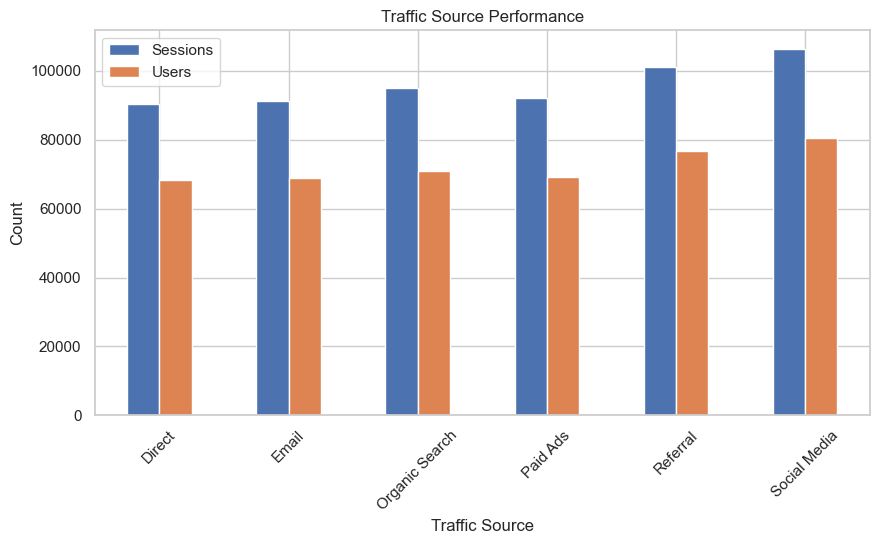

In [49]:
traffic_analysis.plot(kind="bar", figsize=(10,5))

plt.title("Traffic Source Performance")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# user engagement

In [28]:
sns.set(style="whitegrid")

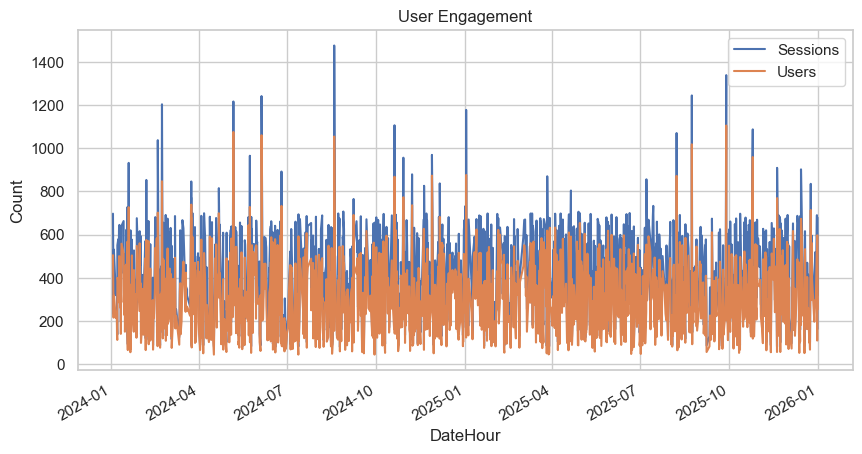

In [36]:
plt.figure(figsize=(10,5))
df.groupby("Date_Hour")[["Sessions","Users"]].sum().plot(ax=plt.gca())
plt.title("User Engagement")
plt.xlabel("DateHour")
plt.ylabel("Count")
plt.show()

# total users by channel

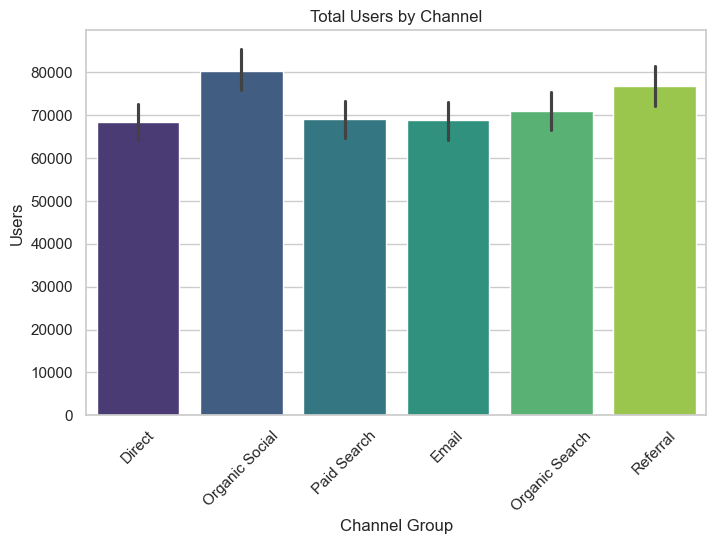

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="Channel Group",
    y="Users",
    hue="Channel Group",
    estimator=np.sum,
    palette="viridis",
    legend=False
)
plt.title("Total Users by Channel")
plt.xticks(rotation=45)
plt.show()

# conversion rates track

In [50]:
total_conversions = df["Conversion Count"].sum()

print("Total Goal Completions:", total_conversions)

Total Goal Completions: 55569


In [51]:
conversion_by_source = df.groupby("Traffic Source")[["Conversion Count", "Conversion Rate (%)"]].mean()

print(conversion_by_source)

                Conversion Count  Conversion Rate (%)
Traffic Source                                       
Direct                 40.380952            13.594848
Email                  36.076271            12.633136
Organic Search         39.532787            13.341926
Paid Ads               32.743802            11.602397
Referral               36.318008            12.377241
Social Media           37.335664            13.096503


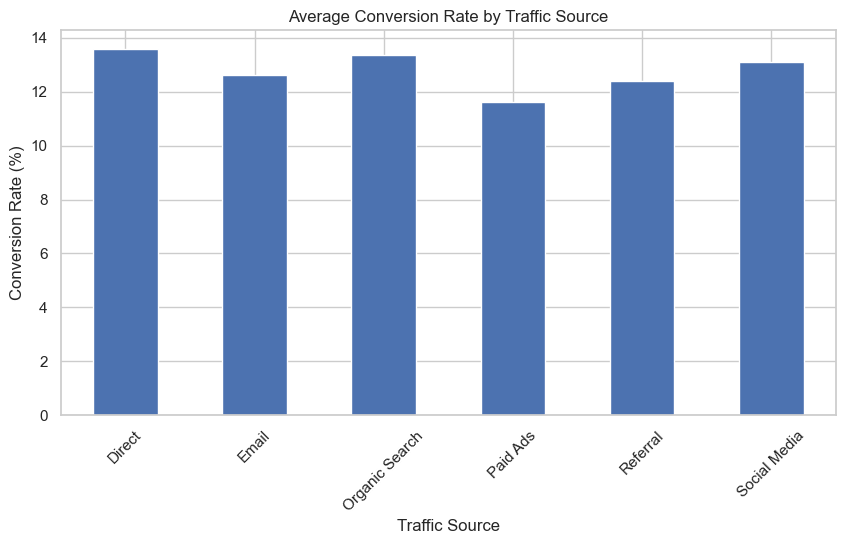

In [52]:
conversion_by_source["Conversion Rate (%)"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Conversion Rate by Traffic Source")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

# high performing & low performing pages

In [53]:
page_performance = df.groupby("Landing Page")[[
    "Sessions",
    "Bounce Rate (%)",
    "Conversion Rate (%)",
    "Engagement Rate (%)"
]].mean()

print(page_performance)


                 Sessions  Bounce Rate (%)  Conversion Rate (%)  \
Landing Page                                                      
/about         396.646667        32.595133            12.359800   
/blog          370.089655        32.983379            13.371448   
/checkout      385.298013        31.743510            12.388874   
/contact       393.378788        34.774470            12.791212   
/features      402.992647        35.125441            11.636544   
/home          403.966887        32.987417            13.298742   
/landing-page  365.897260        36.103562            12.045959   
/pricing       371.384615        32.749167            13.433654   
/services      380.441860        32.019651            13.205523   
/signup        374.757764        32.893292            12.998261   

               Engagement Rate (%)  
Landing Page                        
/about                   67.404867  
/blog                    67.016621  
/checkout                68.256490  
/contact  

In [54]:
high_perf = page_performance.sort_values(
    by="Conversion Rate (%)",
    ascending=False
)

print(high_perf.head())


                Sessions  Bounce Rate (%)  Conversion Rate (%)  \
Landing Page                                                     
/pricing      371.384615        32.749167            13.433654   
/blog         370.089655        32.983379            13.371448   
/home         403.966887        32.987417            13.298742   
/services     380.441860        32.019651            13.205523   
/signup       374.757764        32.893292            12.998261   

              Engagement Rate (%)  
Landing Page                       
/pricing                67.250833  
/blog                   67.016621  
/home                   67.012583  
/services               67.980349  
/signup                 67.106708  


In [55]:
low_perf = page_performance.sort_values(
    by="Bounce Rate (%)",
    ascending=False
)

print(low_perf.head())


                 Sessions  Bounce Rate (%)  Conversion Rate (%)  \
Landing Page                                                      
/landing-page  365.897260        36.103562            12.045959   
/features      402.992647        35.125441            11.636544   
/contact       393.378788        34.774470            12.791212   
/home          403.966887        32.987417            13.298742   
/blog          370.089655        32.983379            13.371448   

               Engagement Rate (%)  
Landing Page                        
/landing-page            63.896438  
/features                64.874559  
/contact                 65.225530  
/home                    67.012583  
/blog                    67.016621  


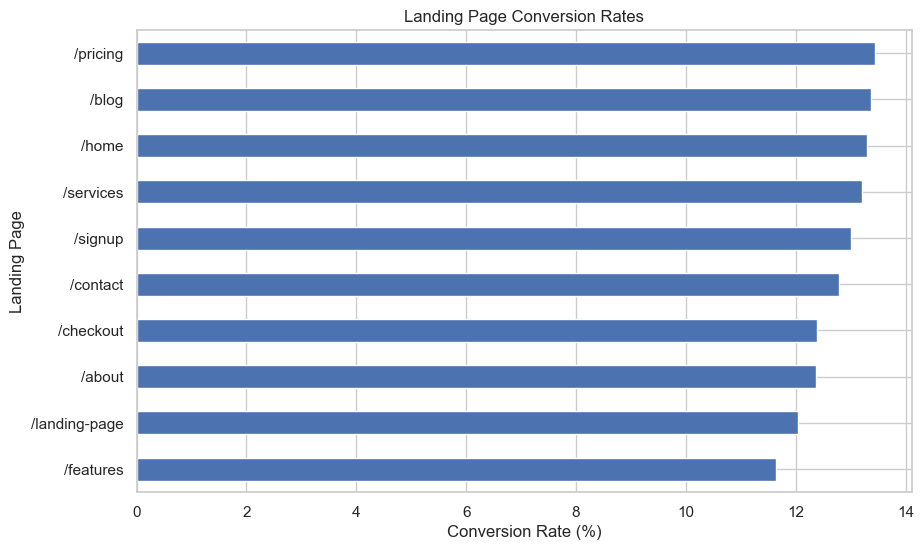

In [56]:
page_performance["Conversion Rate (%)"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Landing Page Conversion Rates")
plt.xlabel("Conversion Rate (%)")
plt.show()

# website traffic analysis dashboard

In [58]:


import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# KPI cards

In [63]:
total_sessions = df["Sessions"].sum()
total_users = df["Users"].sum()
avg_bounce = df["Bounce Rate (%)"].mean()
total_conversions = df["Conversion Count"].sum()

print("Total Sessions:", total_sessions)
print("Total Users:", total_users)
print("Avg Bounce Rate:", round(avg_bounce,2), "%")
print("Total Conversions:", total_conversions)

Total Sessions: 576201
Total Users: 434376
Avg Bounce Rate: 33.33 %
Total Conversions: 55569


# traffic source dashboard

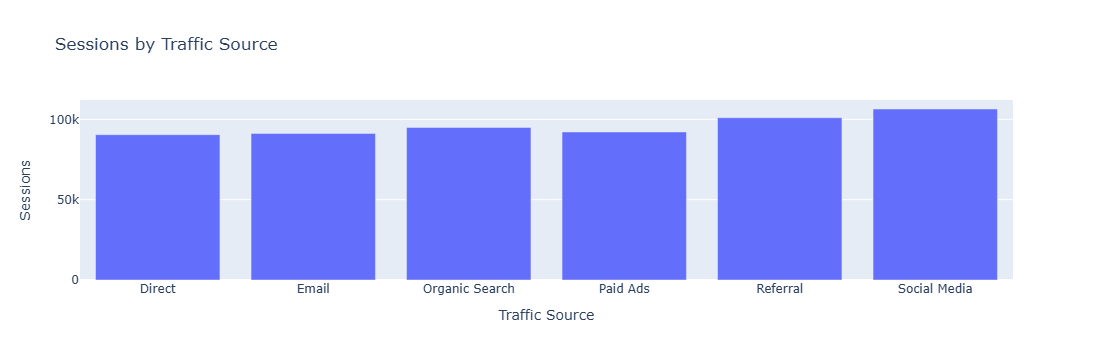

In [64]:
traffic = df.groupby("Traffic Source")["Sessions"].sum().reset_index()

fig = px.bar(
    traffic,
    x="Traffic Source",
    y="Sessions",
    title="Sessions by Traffic Source"
)

fig.show()

# bounce rate dashboard 

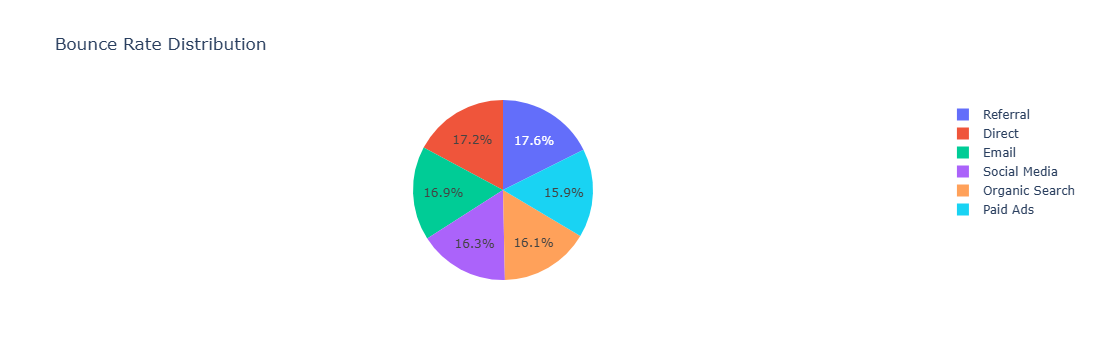

In [65]:
bounce = df.groupby("Traffic Source")["Bounce Rate (%)"].mean().reset_index()

fig = px.pie(
    bounce,
    names="Traffic Source",
    values="Bounce Rate (%)",
    title="Bounce Rate Distribution"
)

fig.show()

# engagement metrics dashboard

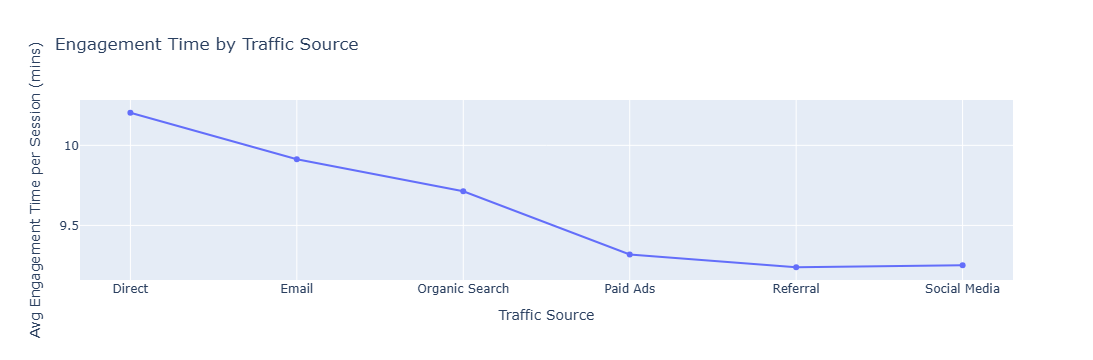

In [66]:
engagement = df.groupby("Traffic Source")[
    "Avg Engagement Time per Session (mins)"
].mean().reset_index()

fig = px.line(
    engagement,
    x="Traffic Source",
    y="Avg Engagement Time per Session (mins)",
    markers=True,
    title="Engagement Time by Traffic Source"
)

fig.show()

# conversion rate dashboard

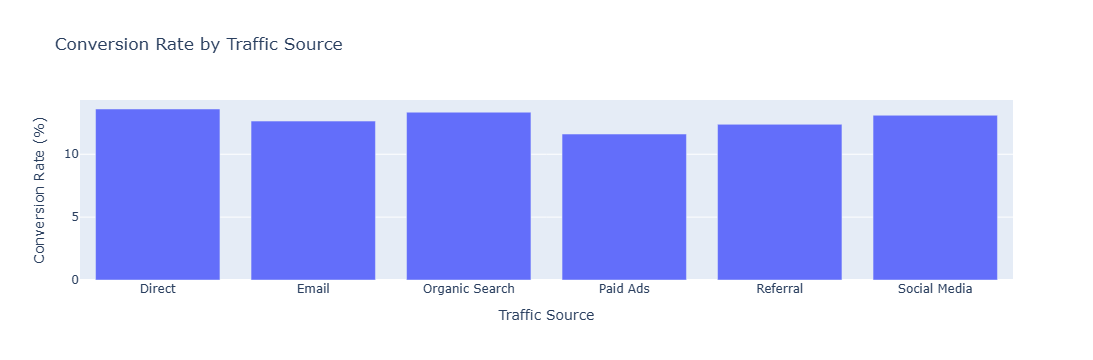

In [67]:
conversion = df.groupby("Traffic Source")[
    "Conversion Rate (%)"
].mean().reset_index()

fig = px.bar(
    conversion,
    x="Traffic Source",
    y="Conversion Rate (%)",
    title="Conversion Rate by Traffic Source"
)

fig.show()

# high & low performimg pages dashboard

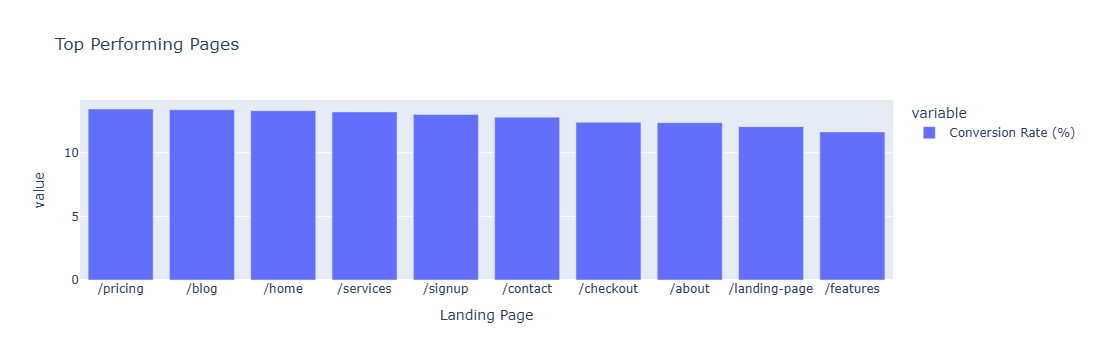

In [68]:
top_pages = df.groupby("Landing Page")[
    "Conversion Rate (%)"
].mean().sort_values(ascending=False).head(10)

fig = px.bar(
    top_pages,
    title="Top Performing Pages"
)

fig.show()

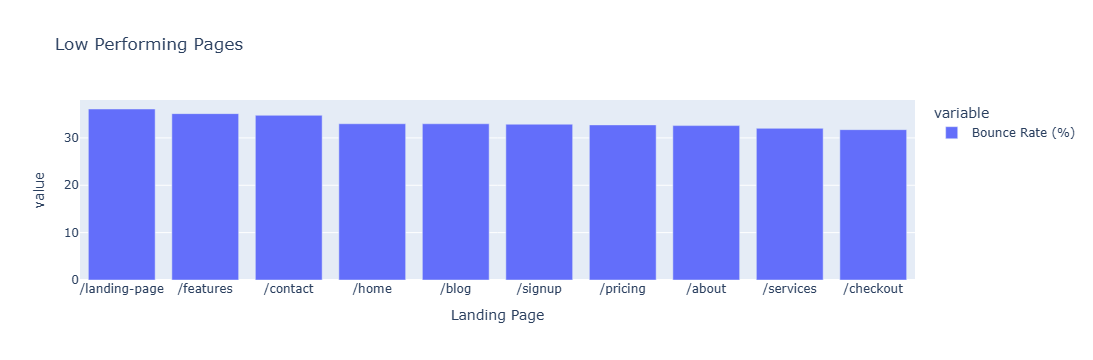

In [69]:
low_pages = df.groupby("Landing Page")[
    "Bounce Rate (%)"
].mean().sort_values(ascending=False).head(10)

fig = px.bar(
    low_pages,
    title="Low Performing Pages"
)

fig.show()

In [70]:
from IPython.display import Markdown

Markdown("""
# Business Insights

- Organic traffic drives maximum sessions.
- Paid traffic has lower engagement.
- Referral traffic shows highest conversion rate.
- Some landing pages have high bounce rates and need optimization.
""")


# Business Insights

- Organic traffic drives maximum sessions.
- Paid traffic has lower engagement.
- Referral traffic shows highest conversion rate.
- Some landing pages have high bounce rates and need optimization.
